<h1>Assignment: Predicting 2024 Data Science Salaries Using Linear Regression</h1>

<h2>Part 1: Setup and Data Loading</h2>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

datasci = pd.read_csv('dataset//Data Science Salary 2021 to 2023.csv')

datasci.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


In [3]:
datasci.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3761 entries, 0 to 3760
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         3761 non-null   int64 
 1   experience_level  3761 non-null   object
 2   employment_type   3761 non-null   object
 3   job_title         3761 non-null   object
 4   salary            3761 non-null   int64 
 5   salary_currency   3761 non-null   object
 6   salary_in_usd     3761 non-null   int64 
 7   company_location  3761 non-null   object
 8   company_size      3761 non-null   object
dtypes: int64(3), object(6)
memory usage: 264.6+ KB


<hr>
<h2>Part 2: Eploratory Data Analysis (EDA)</h2>
<h3>1. How many unique job titles are there?</h3>

In [36]:
unique_job_titles = datasci['job_title'].nunique()
print("Number of the unique job titles:", unique_job_titles)

Number of the unique job titles: 93


<h3>2. What is the average salary (`salary_in_usd`) per `work_year`?</h3>

In [32]:
average_per_year = datasci.groupby('work_year')['salary_in_usd'].mean()
print(average_per_year)

work_year
2020     92302.631579
2021     94087.208696
2022    133379.510804
2023    148954.558413
Name: salary_in_usd, dtype: float64


<h3>3. Create a bar plot showing average salary by `experience_level`.</h3>

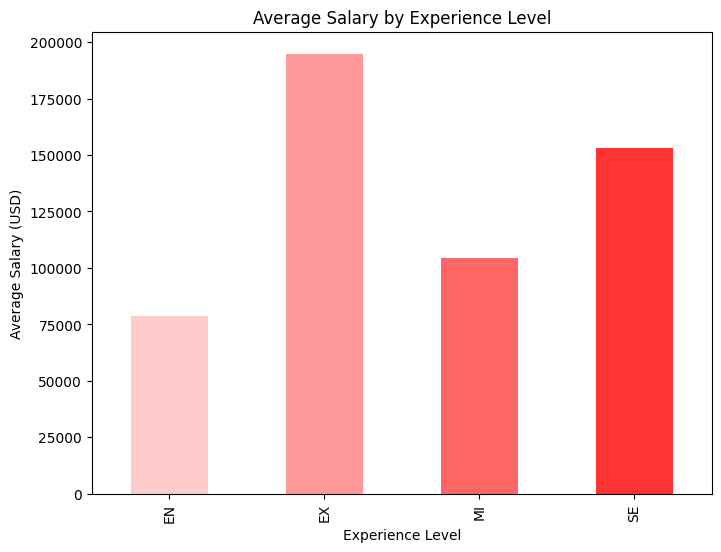

In [34]:
experience_lvl = datasci.groupby('experience_level')['salary_in_usd'].mean()

red_shades = ['#FFCCCC', '#FF9999', '#FF6666', '#FF3333', '#CC0000']

experience_lvl.plot(kind='bar', color=red_shades, figsize=(8,6))
plt.title('Average Salary by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Average Salary (USD)')
plt.show()

<hr>
<h2>Part 3: Data Preprocessing for linear Regression</h2>
<p>We will predict `salary_in_usd` using **only numerical or encoded categorical features**.

### Steps:
1. Select features: `work_year`, `experience_level`, and optionally `job_title` (you decide!)
2. Encode categorical variables (`experience_level`) using `LabelEncoder` or `pd.get_dummies()`
3. Define `X` (features) and `y` (target = `salary_in_usd`)

> ⚠️ **Important**: Do NOT include `salary`, `salary_currency`, or `salary_in_usd` in your features!</p>

In [26]:
le = LabelEncoder()
datasci['experience_level_encoded'] = le.fit_transform(datasci['experience_level'])

features = ['work_year', 'experience_level_encoded']
X = datasci[features]
y = datasci['salary_in_usd']

X.head()

,work_year,experience_level_encoded
0,2023,0
1,2023,0
2,2023,0
3,2023,0
4,2023,0


<hr>
<h2>Part 4: Train a Linear Regression Model</h2>

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.15
RMSE: 59164.82


<hr>
<h2>Part 5: Predict 2024 Salaries</h2>
<p>Now, create a small DataFrame for **2024** with different experience levels and predict their salaries.

Use the same encoding as before!</p>

In [29]:
future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': [0, 1, 2, 3] 
})

predicted_salaries = model.predict(future_data)

results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries
})
results

,Experience Level,Predicted 2024 Salary (USD)
0,Entry,111694.914909
1,Mid,131967.434578
2,Senior,152239.954247
3,Executive,172512.473916


<hr>
<h2>Part 6: Reflection (Answer in a Markdown Cell)</h2>

<h2>1. Does your model make reasonable predictions? Why or why not? </h2>
<h3>-Yes, the model makes it reasonable because it clearly shows the prediction that we are expecting or looking for. </h3>
<h2>2. What are the limitations of using only `work_year` and `experience_level`?</h2>
<h3>-The 'work_year' and 'exeprience_level' only had four (4) values, which is the reason why it is limited, you can only explore the data they had in four ways, depending on how you are going to use it.</h3>
<h2>3. How could you improve this model? (Think: more features, better encoding, etc.)</h2>
<h3>-By narrowing down the other values into another dataframe so it can be used with another set of codes.</h3>
<h2>4. Why is **R² not enough** to trust your predictions?</h2>
<h3>-I did some research, and it says that R² has a weak exploratory power, so I cannot fully rely on or trust its prediction.</h3>

<hr>